# **T3B** Indução Magnética

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.odr import RealData, Model, ODR
import scipy.constants as const
import sys
sys.path.append("../..")
import base as b

C:\Users\appin\AppData\Local\Temp\ipykernel_17132\3438912278.py:3: DeprecationWarning: `scipy.odr` is deprecated as of version 1.17.0 and will be removed in SciPy 1.19.0. Please use `https://pypi.org/project/odrpack/` instead.
  from scipy.odr import RealData, Model, ODR
c:\Users\appin\OneDrive\Documents\GitHub\labs-II\semana3\T3B - Indução Magnética\../..\base\plot.py:178: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  ax.axhline(stdy, c="orange", label="Intervalo {}$\sigma$".format(tol))


In [2]:
def uni0(x):
    return np.round(0.006*x+0.003,1)

## $\omega$

In [3]:
V,i0,f,w,i0w,n,d,S,theta = b.getData("omega2.txt")
V,uV,i0,ui0,f,uf=b.getData('exp_w.txt')
w=np.round(f*2*np.pi,2)
uw=np.round(uf*2*np.pi,2)
print(w,uw)

[ 1.45  1.95  2.26  2.64  3.27  3.83  5.22  5.91  6.72  7.41  8.29  9.11
 10.37 12.32 13.57 14.58 15.77 17.03 18.35] [0.06 0.06 0.06 0.06 0.06 0.06 0.06 0.06 0.06 0.06 0.06 0.06 0.06 0.06
 0.06 0.06 0.06 0.06 0.06]


Beta: [ 8.4205414e-05 -5.1188174e-03]
Beta Std Error: [2.99678951e-07 2.15100815e-03]
Beta Covariance: [[ 5.50748129e-14 -3.13426544e-10]
 [-3.13426544e-10  2.83742678e-06]]
Residual Variance: 1.6306450998656297
Inverse Condition #: 8.489997139315751e-05
Reason(s) for Halting:
  Sum of squares convergence
Beta: [ 0.00023312 -0.00541892]
Beta Std Error: [3.01926868e-07 1.08307783e-03]
Beta Covariance: [[ 1.43685032e-14 -4.31095815e-11]
 [-4.31095815e-11  1.84895924e-07]]
Residual Variance: 6.34442101092497
Inverse Condition #: 0.00015279352162460752
Reason(s) for Halting:
  Sum of squares convergence


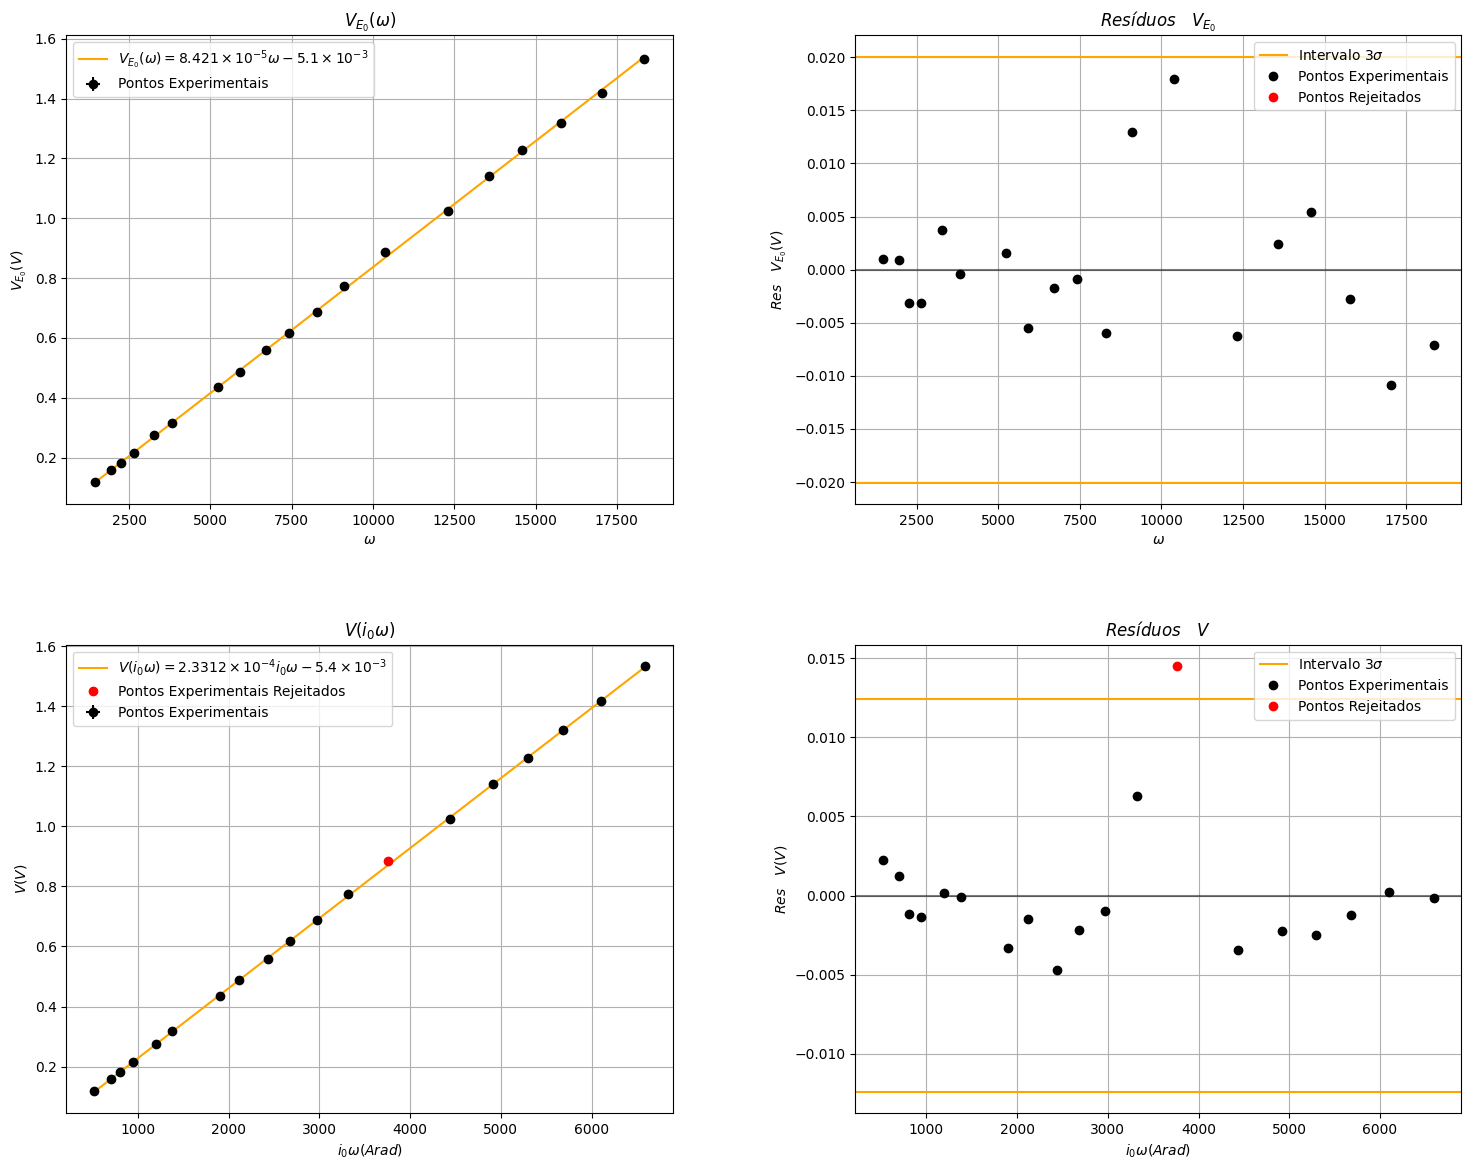

In [4]:
xs = [w*1000,i0w]
ys = [V,V]
xerrs = [uw*1000/2,0.01]
yerrs = [uV/2,0.001]
titles = ["V_{E_0} (\\omega)", "V(i_0\\omega)"]
xlabels = ["\\omega","i_0\\omega (Arad)"]
ylabels = ["V_{E_0}(V)","V(V)"]

wad = b.plotColumnFullLinReg(xs,ys,xerrs,yerrs,titles,xlabels,ylabels,tol=3)
for i in wad:
    i.pprint()

In [5]:
#realMiu0 = const.mu_0
realMiu0=4*np.pi*1e-7
N = 364
n = n[0]
S = S[0]*1e-6
L = .75
i = np.average(i0/1000)
ui = np.std(i0/1000)/np.sqrt(len(i0))
# 
#ajuste i0
dec = wad[0].beta[0]
udec = wad[0].sd_beta[0]
dec,udec,l=b.round_un(dec,udec)
miu0 = dec/(N*n*S*i)*L
inc = np.sqrt((1/(N*n*S*i)*L*udec)**2+(dec/(N*n*S*i**2)*L*ui)**2)
miu0,inc,l=b.round_un(miu0,inc)
m1,um1=miu0,inc
print(f"Ajuste V(i0):\nμ0 = {miu0:.4e} H/m\nincerteza={inc:.3e} H/m\ndesvio = {abs(miu0-realMiu0)/realMiu0*100:.3f}%\n")

#ajuste i0w
dec = wad[1].beta[0]
udec = wad[1].sd_beta[0]
dec,udec,l=b.round_un(dec,udec)
miu0 = dec/(N*n*S)*L
inc = udec/(N*n*S)*L
miu0,inc,l=b.round_un(miu0,inc)
print(f"Ajuste V(w):\nμ0 = {miu0:.4e} H/m\nincerteza={inc:.3e} H/m\ndesvio = {abs(miu0-realMiu0)/realMiu0*100:.3f}%\n")

Ajuste V(i0):
μ0 = 1.2139e-06 H/m
incerteza=4.800e-09 H/m
desvio = 3.401%

Ajuste V(w):
μ0 = 1.2127e-06 H/m
incerteza=1.600e-09 H/m
desvio = 3.496%



## $i_0$

Beta: [4.39041984 0.01369787]
Beta Std Error: [0.00437939 0.0008526 ]
Beta Covariance: [[ 9.74598286e-04 -1.65433428e-04]
 [-1.65433428e-04  3.69395234e-05]]
Residual Variance: 0.01967893990326455
Inverse Condition #: 0.08756188241965508
Reason(s) for Halting:
  Sum of squares convergence
Beta: [7.59534573 0.02144625]
Beta Std Error: [0.00507863 0.00049689]
Beta Covariance: [[ 1.76165354e-03 -1.30896602e-04]
 [-1.30896602e-04  1.68631893e-05]]
Residual Variance: 0.014641082006134228
Inverse Condition #: 0.06253900846562888
Reason(s) for Halting:
  Sum of squares convergence


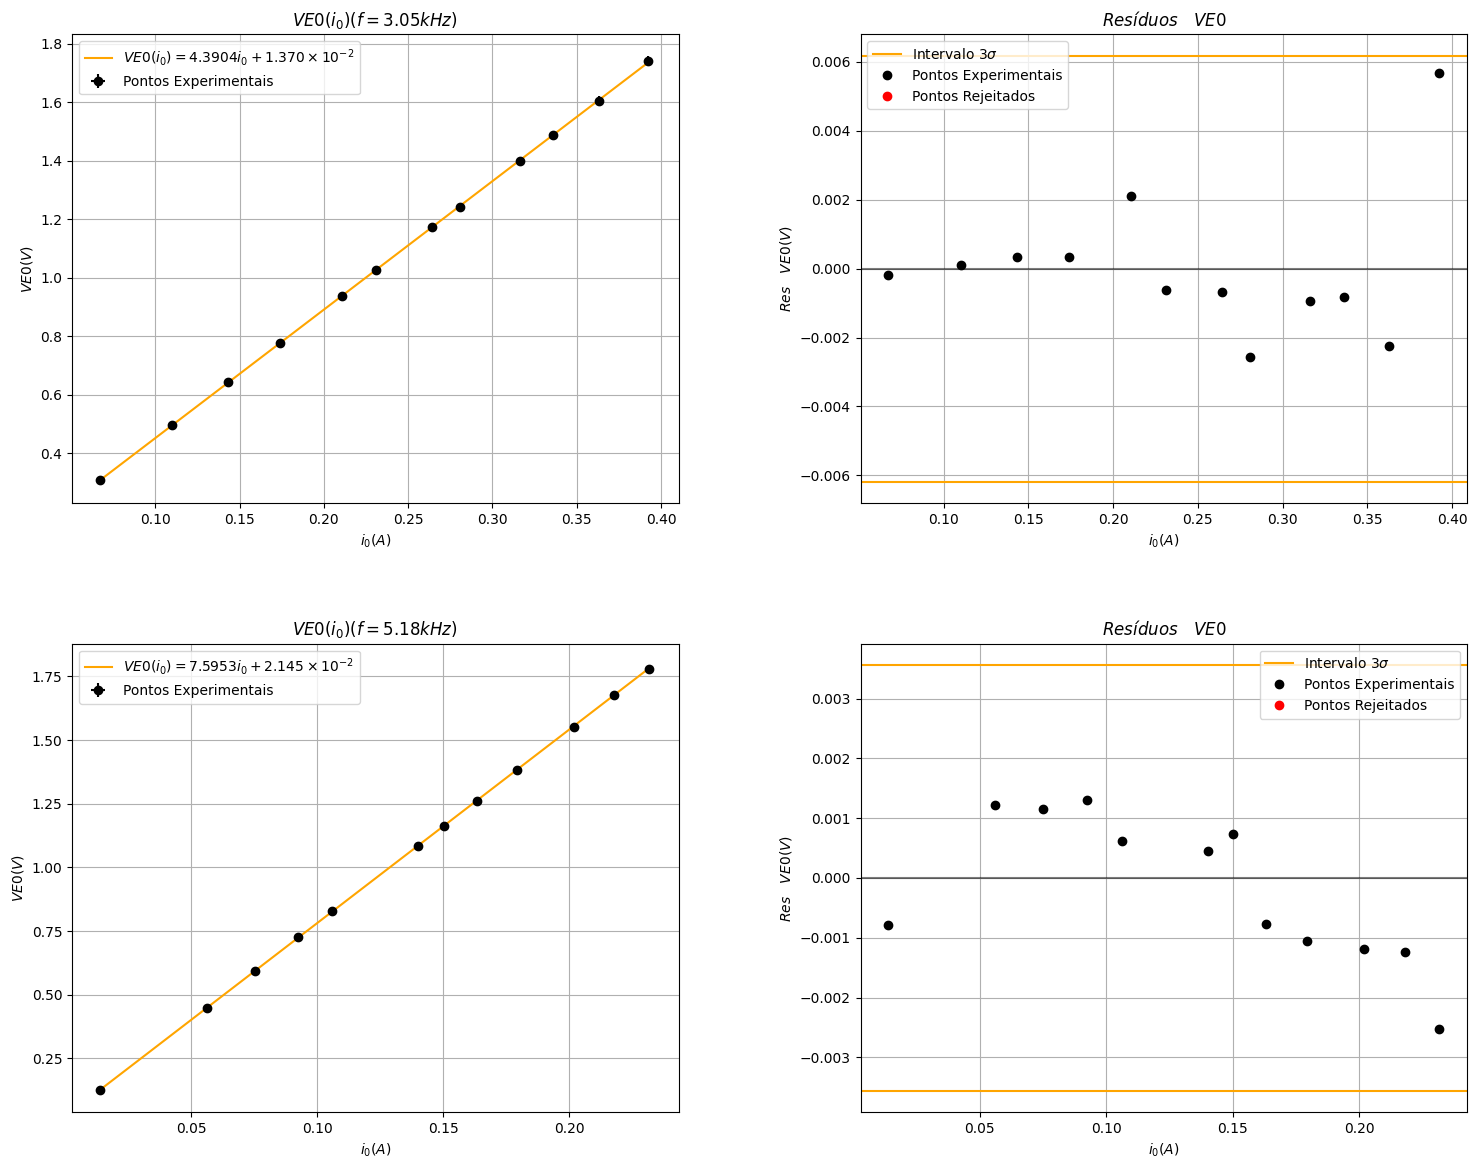

In [6]:
V,i0,f,n,d,S,theta = b.getData("i0_12.txt")
V,uV,i0,ui0=b.getData('exp_i0.txt')
V2,i02,f2,n2,d2,S2,theta2 = b.getData("i0_22.txt")
V2,uV2,i02,ui02=b.getData('exp_i02.txt')
i0ad = b.plotColumnFullLinReg([i0/1000,i02/1000],[V,V2],[ui0/2000,ui02/2000],[uV,uV2],[f"VE0(i_0) (f={f[0]}kHz)",f"VE0(i_0) (f={f2[0]}kHz)"], ["i_0(A)","i_0(A)"],["VE0(V)","VE0(V)"],tol=3)
for i in i0ad:
    i.pprint()

In [7]:
n = n[0]
S = S[0]*1e-6
w=f[0]*2000*np.pi
uw = np.round(10*2*np.pi,2)
#print(uw)

#print(n,S,N,w,L)

#ajuste w1
dec = i0ad[0].beta[0]
udec = i0ad[0].sd_beta[0]
dec,udec,l=b.round_un(dec,udec)
print(dec,udec)
miu0 = dec/(N*n*S*w)*L
inc = np.sqrt((1/(N*n*S*w)*L*udec)**2+(dec/(N*n*S*w**2)*L*uw)**2)
miu0,inc,l=b.round_un(miu0,inc)
m2,um2=miu0,inc

print(f"Ajuste 1 V(i0):\nμ0 = {miu0:.4e} H/m\nincerteza={inc:.3e} H/m\ndesvio = {abs(miu0-realMiu0)/realMiu0*100:.3f}%\n")

#ajuste w2
w=f2[0]*2000*np.pi
uw = np.round(10*2*np.pi)
dec = i0ad[1].beta[0]
udec = i0ad[1].sd_beta[0]
dec,udec,l=b.round_un(dec,udec)
print(dec,udec)
miu0 = dec/(N*n*S*w)*L
inc = np.sqrt((1/(N*n*S*w)*L*udec)**2+(dec/(N*n*S*w**2)*L*uw)**2)
miu0,inc,l=b.round_un(miu0,inc)
m3,um3=miu0,inc
print(f"Ajuste 2 V(i0):\nμ0 = {miu0:.4e} H/m\nincerteza={inc:.3e} H/m\ndesvio = {abs(miu0-realMiu0)/realMiu0*100:.3f}%\n")

4.3904 0.0044
Ajuste 1 V(i0):
μ0 = 1.1918e-06 H/m
incerteza=4.100e-09 H/m
desvio = 5.160%

7.5953 0.0051
Ajuste 2 V(i0):
μ0 = 1.2140e-06 H/m
incerteza=2.500e-09 H/m
desvio = 3.393%



## $n$

Beta: [ 0.00448332 -0.00091954]
Beta Std Error: [5.22751439e-05 1.37811170e-02]
Beta Covariance: [[ 6.83074023e-10 -1.56962396e-07]
 [-1.56962396e-07  4.74729408e-05]]
Residual Variance: 4.000577651547149
Inverse Condition #: 0.001856525989311768
Reason(s) for Halting:
  Sum of squares convergence


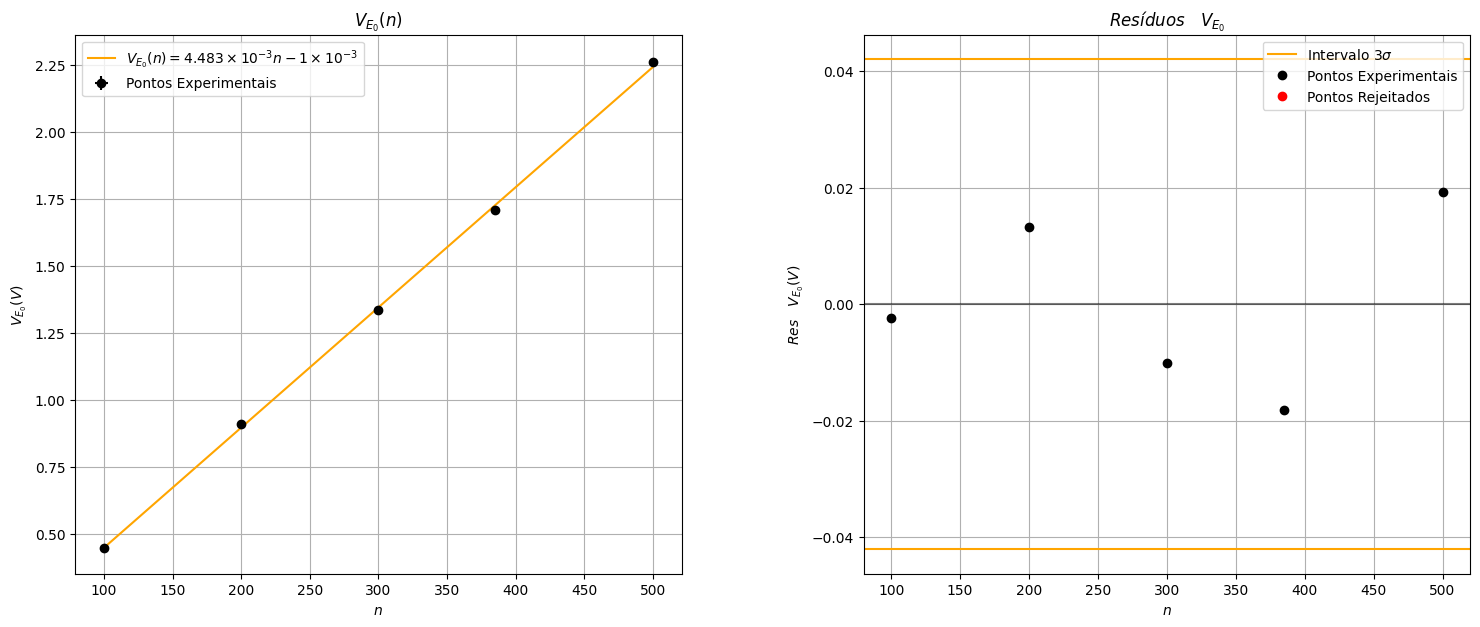

In [8]:
V,n,f,i0,d,S,theta = b.getData("n2.txt")
V,uV,=b.getData('exp_n.txt')
#print(len(V),len(n))

nad = b.plotColumnFullLinReg([n],[V],[1],[uV/2],["V_{E_0}(n)"], ["n"],["V_{E_0}(V)"],tol=3)
nad[0].pprint()

In [9]:
i = i0[0]/1000
ui = uni0(i0[0])/1000
S = S[0]*1e-6
w=f[0]*2000*np.pi
uw = 10*2*np.pi


dec = nad[0].beta[0]
udec = nad[0].sd_beta[0]
dec,udec,l=b.round_un(dec,udec)
print(dec,udec)

miu0 = dec*L/(N*S*w*i)
inc = np.sqrt((1/(N*S*w*i)*L*udec)**2+(dec/(N*S*w**2*i)*L*uw)**2+(dec/(N*S*w*i**2)*L*ui)**2)
miu0,inc,l=b.round_un(miu0,inc)
m4,um4=miu0,inc
print(f"Ajuste 2 V(n):\nμ0 = {miu0:.3e} H/m\nincerteza={inc:.3e} H/m\ndesvio = {abs(miu0-realMiu0)/realMiu0*100:.3f}%\n")

0.004483 5.2e-05
Ajuste 2 V(n):
μ0 = 1.245e-06 H/m
incerteza=1.600e-08 H/m
desvio = 0.926%



## $S$

Beta: [0.00099059 0.03167046]
Beta Std Error: [1.93628446e-05 1.54915767e-02]
Beta Covariance: [[ 9.44689067e-11 -7.07437853e-08]
 [-7.07437853e-08  6.04702562e-05]]
Residual Variance: 3.96871060498991
Inverse Condition #: 0.0004396627619514741
Reason(s) for Halting:
  Sum of squares convergence


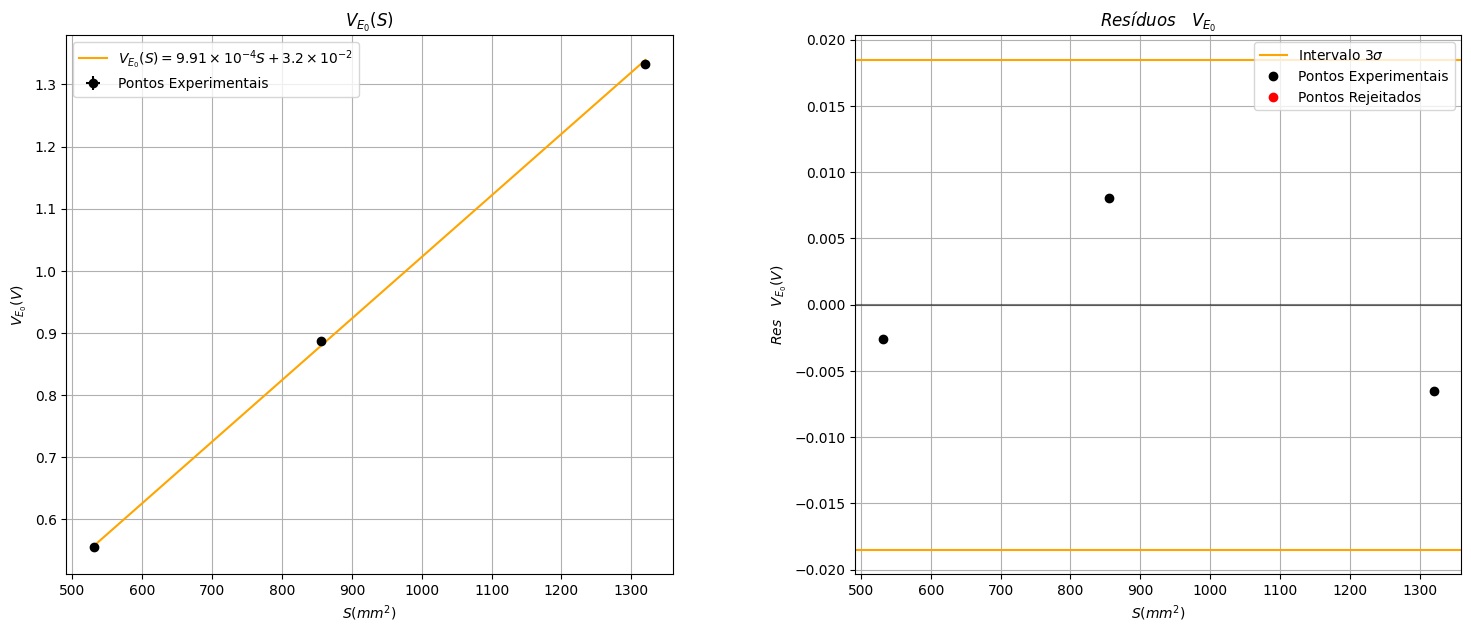

In [10]:
V,d,S,f,i0,n,theta = b.getData("s2.txt")
uV=np.array([0.014,0.010,0.0074])
#print(S,V)

Sad = b.plotColumnFullLinReg([S],[V],[.0000001],[uV/2],["V_{E_0}(S)"], ["S(mm^2)"],["V_{E_0}(V)"],tol=3)
Sad[0].pprint()

In [11]:
i = i0[0]/1000
ui = uni0(i0[0])/1000
n = n[0]
w=f[0]*2000*np.pi
uw = 10*2*np.pi

dec = Sad[0].beta[0]/1e-6
udec = Sad[0].sd_beta[0]/1e-6
dec,udec,l=b.round_un(dec,udec)


miu0 = dec*L/(N*n*w*i)
inc = np.sqrt((1/(N*n*w*i)*L*udec)**2+(dec/(N*n*w**2*i)*L*uw)**2+(dec/(N*n*w*i**2)*L*ui)**2)
miu0,inc,l=b.round_un(miu0,inc)
m5,um5=miu0,inc
print(f"Ajuste 2 V(S):\nμ0 = {miu0:.3e} H/m\nincerteza={inc:.3e} H/m\ndesvio = {abs(miu0-realMiu0)/realMiu0*100:.3f}%\n")

Ajuste 2 V(S):
μ0 = 1.214e-06 H/m
incerteza=2.400e-08 H/m
desvio = 3.393%



## $\theta$

Beta: [0.15158202 0.00930441]
Beta Std Error: [0.00212473 0.00208535]
Beta Covariance: [[ 0.00047781 -0.00046698]
 [-0.00046698  0.00046026]]
Residual Variance: 0.009448334252797763
Inverse Condition #: 0.04448821452863312
Reason(s) for Halting:
  Sum of squares convergence


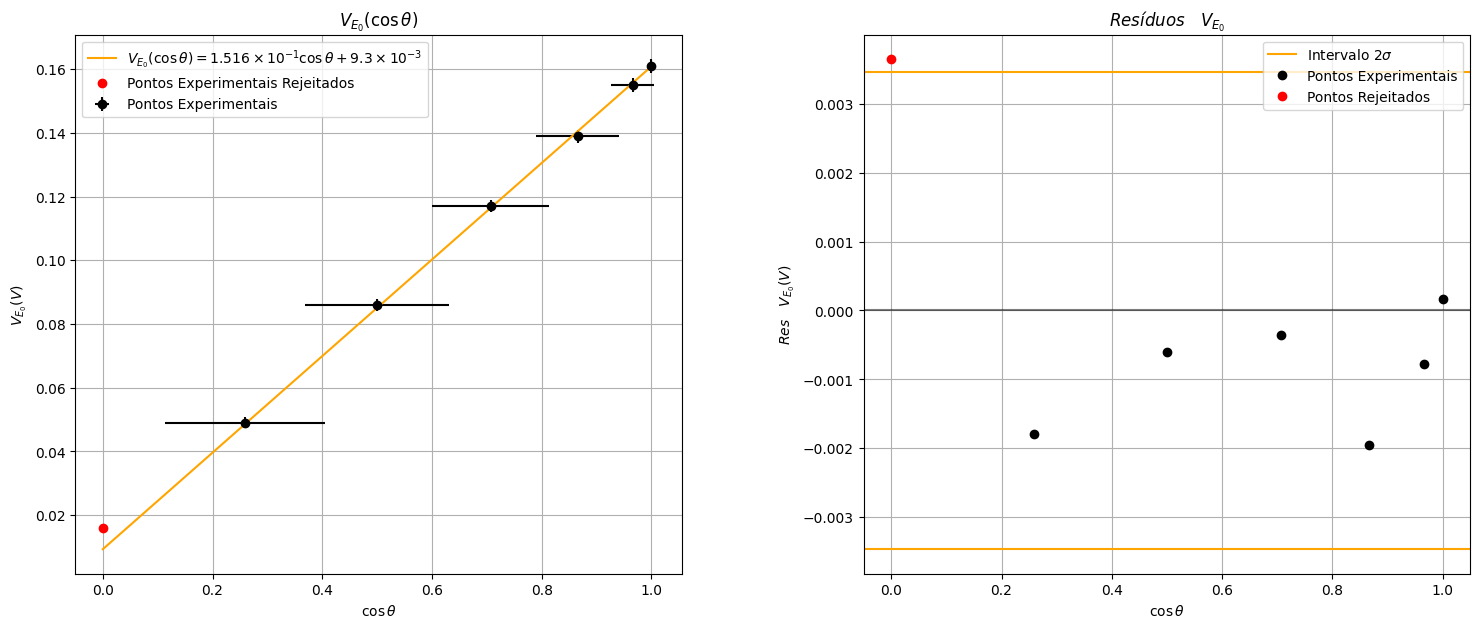

In [12]:
V,theta,cos,f,i0,n,S = b.getData("theta2.txt")
V,uV,theta,utheta,cos,ucos=b.getData('exp_t.txt')

tad = b.plotColumnFullLinReg([cos],[V],[ucos],[uV/2],["V_{E_0}(\\cos{ \\theta })"], [r"\cos{ \theta }"],["V_{E_0}(V)"],tol=2)
tad[0].pprint()

In [13]:
i = i0[0]/1000
ui = uni0(i0[0])/1000
n = n[0]
w=f[0]*2000*np.pi
uw = 10*2*np.pi
S = S[0]*1e-6


dec = tad[0].beta[0]
udec = tad[0].sd_beta[0]
dec,udec,l=b.round_un(dec,udec)
miu0 = dec*L/(N*n*w*i*S)
inc = np.sqrt((1/(N*n*w*i*S)*L*udec)**2+(dec/(N*n*w**2*i*S)*L*uw)**2+(dec/(N*n*w*i**2*S)*L*ui)**2)
miu0,inc,l=b.round_un(miu0,inc)
m6,um6=miu0,inc
print(f"Ajuste 2 V(S):\nμ0 = {miu0:.3e} H/m\nincerteza={inc:.3e} H/m\ndesvio = {abs(miu0-realMiu0)/realMiu0*100:.3f}%\n")

Ajuste 2 V(S):
μ0 = 1.110e-06 H/m
incerteza=1.700e-08 H/m
desvio = 11.669%



In [14]:
u0f=(m1+m2+m3+m4+m5+m6)/6
un=np.sqrt(um1**2+um2**2+um3**2+um4**2+um5**2+um6**2)
u0f,un,l=b.round_un(u0f,un)
print(u0f,un)
abs(u0f-realMiu0)/realMiu0*100

1.198e-06 3.4e-08


np.float64(4.666189087954693)

In [15]:
abs(1.194-4*np.pi*1e-1)/(4*np.pi*1e-1)*100

4.984498974138485

In [16]:
1.197+0.034*2

1.2650000000000001

In [17]:
b.round_un(1.4555,0.0989)

array([1.456, 0.099, 3.   ])

In [18]:
ODR(wf,af,

_IncompleteInputError: incomplete input (3211406538.py, line 1)